In [32]:
# ============================================================
# GENE THERAPY CLINICAL TRIALS DATASET ANALYSIS
# Questions:
# 1. Which diseases have most gene therapy trials?
# 2. Which vectors are used most?
# 3. Which phases are most common?
# 4. Which sponsors run most trials?
# 5. Which years saw the most trials?
# 6. Which indications are growing?
# ============================================================

In [17]:
# ----------------------------
# Part 1: Import libraries
# ----------------------------

# requests lets us download data from the ClinicalTrials.gov API
import requests

# pandas lets us work with the data as a table
import pandas as pd

# matplotlib lets us create graphs
import matplotlib.pyplot as plt

In [18]:
# ----------------------------
# Part 2: Download gene therapy clinical trials
# ----------------------------

# This API searches ClinicalTrials.gov for studies containing "gene therapy"
# We ask for 1000 results so we get a bigger dataset.

url = "https://clinicaltrials.gov/api/v2/studies"

params = {
    "query.term": "gene therapy",
    "pageSize": 1000,
    "format": "json"
}

response = requests.get(url, params=params)

# Check whether the API request worked
print("Status code:", response.status_code)

# Convert the response into Python dictionary format
data = response.json()

# Check how many studies we downloaded
print("Number of studies downloaded:", len(data["studies"]))

Status code: 200
Number of studies downloaded: 1000


In [19]:
# ----------------------------
# Part 3: Convert API data into a pandas dataframe
# ----------------------------

# ClinicalTrials.gov gives us nested JSON.
# This loop extracts only the useful fields we need.

rows = []

for study in data["studies"]:
    protocol = study.get("protocolSection", {})

    identification = protocol.get("identificationModule", {})
    status = protocol.get("statusModule", {})
    design = protocol.get("designModule", {})
    sponsor = protocol.get("sponsorCollaboratorsModule", {})
    conditions = protocol.get("conditionsModule", {})
    interventions = protocol.get("armsInterventionsModule", {})

    nct_id = identification.get("nctId")
    title = identification.get("briefTitle")

    overall_status = status.get("overallStatus")

    # Start date is nested, so we safely extract it
    start_date_struct = status.get("startDateStruct", {})
    start_date = start_date_struct.get("date")

    # Trial phases are usually stored as a list
    phases = design.get("phases", [])

    # Lead sponsor
    lead_sponsor = sponsor.get("leadSponsor", {}).get("name")

    # Diseases / conditions
    condition_list = conditions.get("conditions", [])

    # Interventions may include gene therapies, drugs, biological products, procedures, etc.
    intervention_list = interventions.get("interventions", [])

    intervention_names = []
    intervention_types = []

    for intervention in intervention_list:
        intervention_names.append(intervention.get("name"))
        intervention_types.append(intervention.get("type"))

    rows.append({
        "nct_id": nct_id,
        "title": title,
        "status": overall_status,
        "start_date": start_date,
        "phases": phases,
        "lead_sponsor": lead_sponsor,
        "conditions": condition_list,
        "intervention_names": intervention_names,
        "intervention_types": intervention_types
    })

df = pd.DataFrame(rows)

df.head()

,nct_id,title,status,start_date,phases,lead_sponsor,conditions,intervention_names,intervention_types
0,NCT05793190,Gut Mycobiome Profile in Alcoholic Liver Disease.,UNKNOWN,2021-04-15,[],Chuncheon Sacred Heart Hospital,[Alcoholic Liver Disease],[],[]
1,NCT04095546,Epigenetic Changes in Psychotherapy of Adolesc...,WITHDRAWN,2022-04,[],"University Hospital, Basel, Switzerland",[Borderline Personality Disorder (BPD)],[routine psychotherapy for Borderline Personal...,[OTHER]
2,NCT00228488,Effect of Iressa With/Without Concurrent Chemo...,COMPLETED,2004-06,[PHASE2],AstraZeneca,[Head and Neck Cancer],[Gefitinib],[DRUG]
3,NCT00005988,Bone Marrow Transplantation With Specially Tre...,COMPLETED,2000-02,[PHASE1],Dana-Farber Cancer Institute,"[Graft Versus Host Disease, Leukemia, Lymphoma...","[cyclophosphamide, cyclosporine, leucovorin ca...","[DRUG, DRUG, DRUG, DRUG, DRUG, PROCEDURE, RADI..."
4,NCT07213440,Identification of Early Markers for ALS,RECRUITING,2024-09-30,[NA],Institut National de la Santé Et de la Recherc...,[Amyotrophic Lateral Sclerosis (ALS)],[lumbar puncture],[PROCEDURE]


In [20]:
# ----------------------------
# Part 4: Basic exploration
# ----------------------------

# See the size of the dataset
print("Rows:", len(df))
print("Columns:", len(df.columns))

# See column names
print("\nColumns:")
print(list(df.columns))

# See data types and missing values
df.info()

Rows: 1000
Columns: 9

Columns:
['nct_id', 'title', 'status', 'start_date', 'phases', 'lead_sponsor', 'conditions', 'intervention_names', 'intervention_types']
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   nct_id              1000 non-null   str   
 1   title               1000 non-null   str   
 2   status              1000 non-null   str   
 3   start_date          990 non-null    str   
 4   phases              1000 non-null   object
 5   lead_sponsor        1000 non-null   str   
 6   conditions          1000 non-null   object
 7   intervention_names  1000 non-null   object
 8   intervention_types  1000 non-null   object
dtypes: object(4), str(5)
memory usage: 70.4+ KB


In [21]:
# ----------------------------
# Part 5: Clean start date and extract year
# ----------------------------

# Convert start_date into datetime format
df["start_date"] = pd.to_datetime(df["start_date"], errors="coerce")

# Extract only the year
df["start_year"] = df["start_date"].dt.year

df[["nct_id", "title", "start_date", "start_year"]].head()

,nct_id,title,start_date,start_year
0,NCT05793190,Gut Mycobiome Profile in Alcoholic Liver Disease.,2021-04-15,2021.0
1,NCT04095546,Epigenetic Changes in Psychotherapy of Adolesc...,NaT,NaN
2,NCT00228488,Effect of Iressa With/Without Concurrent Chemo...,NaT,NaN
3,NCT00005988,Bone Marrow Transplantation With Specially Tre...,NaT,NaN
4,NCT07213440,Identification of Early Markers for ALS,2024-09-30,2024.0


In [22]:
# ----------------------------
# Part 6: Explode list columns
# ----------------------------

# Some trials have multiple diseases, phases, or interventions.
# explode() turns each item in a list into its own row.

conditions_df = df[["nct_id", "conditions"]].explode("conditions")
phases_df = df[["nct_id", "phases"]].explode("phases")
interventions_df = df[["nct_id", "intervention_names", "intervention_types"]].explode(
    ["intervention_names", "intervention_types"]
)

conditions_df.head()

,nct_id,conditions
0,NCT05793190,Alcoholic Liver Disease
1,NCT04095546,Borderline Personality Disorder (BPD)
2,NCT00228488,Head and Neck Cancer
3,NCT00005988,Graft Versus Host Disease
3,NCT00005988,Leukemia


In [23]:
# ----------------------------
# Part 7: Clean missing/blank values
# ----------------------------

conditions_df = conditions_df.dropna(subset=["conditions"])
phases_df = phases_df.dropna(subset=["phases"])
interventions_df = interventions_df.dropna(subset=["intervention_names"])

# Remove weird empty strings if present
conditions_df = conditions_df[conditions_df["conditions"].astype(str).str.strip() != ""]
phases_df = phases_df[phases_df["phases"].astype(str).str.strip() != ""]
interventions_df = interventions_df[interventions_df["intervention_names"].astype(str).str.strip() != ""]

print("Condition rows:", len(conditions_df))
print("Phase rows:", len(phases_df))
print("Intervention rows:", len(interventions_df))

Condition rows: 2388
Phase rows: 786
Intervention rows: 1966


In [24]:
# ============================================================
# QUESTION 1:
# Which diseases have most gene therapy trials?
# ============================================================

# Count how many times each disease/condition appears
disease_counts = conditions_df["conditions"].value_counts()

print("Top 10 diseases with most gene therapy trials:")
print(disease_counts.head(10))

Top 10 diseases with most gene therapy trials:
conditions
Breast Cancer                 40
Cancer                        13
Non Small Cell Lung Cancer    12
Prostate Cancer               12
Obesity                       12
Lung Cancer                   11
Leukemia                      10
Breast Neoplasms              10
Migraine                       9
Non-Small Cell Lung Cancer     9
Name: count, dtype: int64


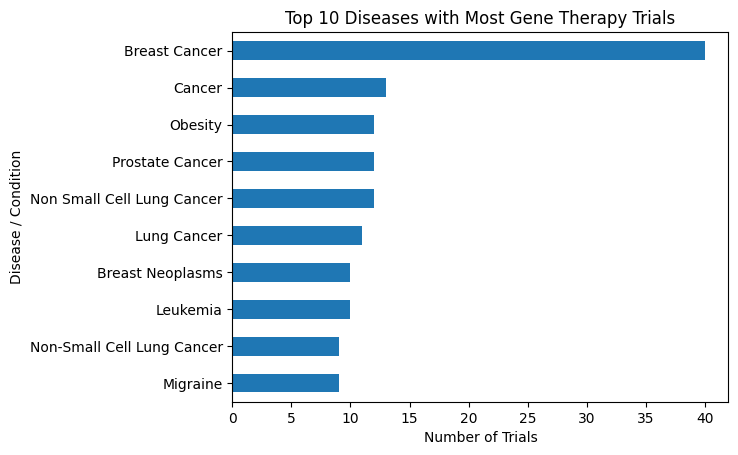

In [25]:
# Plot top diseases

disease_counts.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Diseases with Most Gene Therapy Trials")
plt.xlabel("Number of Trials")
plt.ylabel("Disease / Condition")
plt.show()

In [26]:
# ============================================================
# QUESTION 2:
# Which vectors are used most?
# ============================================================

# ClinicalTrials.gov does not always have a clean "vector" column.
# So we search intervention names for common gene therapy vector words.

vector_keywords = {
    "AAV": "AAV|adeno-associated",
    "Adenovirus": "adenovirus|adenoviral",
    "Lentivirus": "lentivirus|lentiviral",
    "Retrovirus": "retrovirus|retroviral",
    "HSV": "herpes simplex|HSV",
    "Plasmid": "plasmid",
    "mRNA": "mRNA|messenger RNA",
    "CRISPR": "CRISPR|Cas9",
    "CAR-T": "CAR-T|CAR T|chimeric antigen receptor"
}

vector_counts = {}

for vector, pattern in vector_keywords.items():
    matches = interventions_df[
        interventions_df["intervention_names"].astype(str).str.contains(
            pattern,
            case=False,
            na=False,
            regex=True
        )
    ]

    # Count unique trials, not just rows
    vector_counts[vector] = matches["nct_id"].nunique()

vector_counts = pd.Series(vector_counts).sort_values(ascending=False)

print("Most commonly mentioned gene therapy vectors / platforms:")
print(vector_counts)

Most commonly mentioned gene therapy vectors / platforms:
CAR-T         13
AAV            9
Adenovirus     3
Retrovirus     2
Plasmid        2
Lentivirus     1
mRNA           1
HSV            0
CRISPR         0
dtype: int64


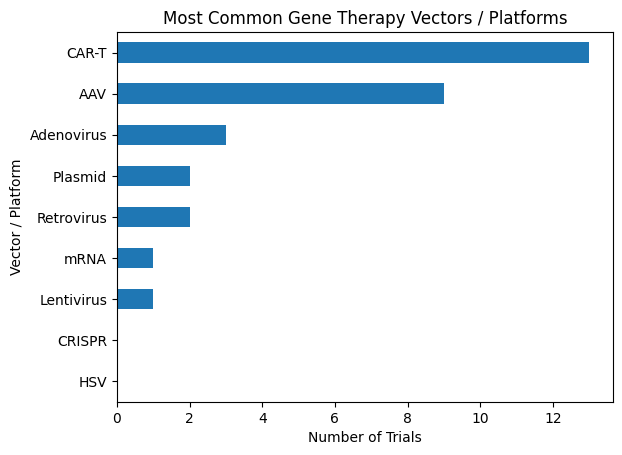

In [27]:
# Plot vector/platform counts

vector_counts.sort_values().plot(kind="barh")

plt.title("Most Common Gene Therapy Vectors / Platforms")
plt.xlabel("Number of Trials")
plt.ylabel("Vector / Platform")
plt.show()

In [28]:
# ============================================================
# QUESTION 3:
# Which phases are most common?
# ============================================================

# Count trial phases
phase_counts = phases_df["phases"].value_counts()

print("Most common trial phases:")
print(phase_counts)

Most common trial phases:
phases
PHASE2          276
PHASE1          197
NA              178
PHASE3           67
PHASE4           46
EARLY_PHASE1     22
Name: count, dtype: int64


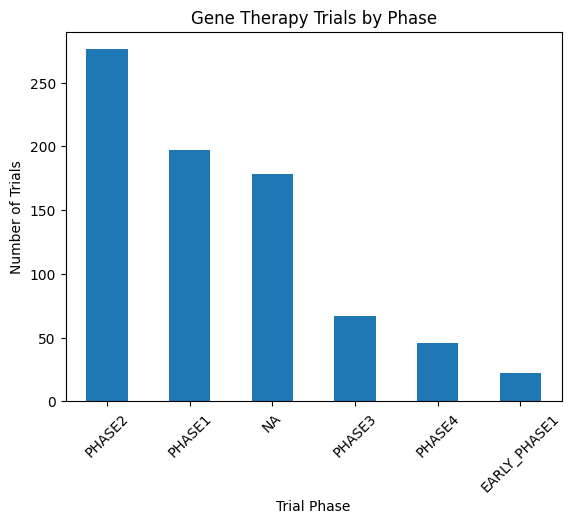

In [29]:
# Plot phase counts

phase_counts.plot(kind="bar")

plt.title("Gene Therapy Trials by Phase")
plt.xlabel("Trial Phase")
plt.ylabel("Number of Trials")
plt.xticks(rotation=45)
plt.show()

In [30]:
# ============================================================
# QUESTION 4:
# Which sponsors run most trials?
# ============================================================

# Count trials by lead sponsor
sponsor_counts = df["lead_sponsor"].value_counts()

print("Top 10 sponsors running gene therapy trials:")
print(sponsor_counts.head(10))

Top 10 sponsors running gene therapy trials:
lead_sponsor
National Cancer Institute (NCI)                                  41
M.D. Anderson Cancer Center                                      16
Baylor College of Medicine                                       14
Assistance Publique - Hôpitaux de Paris                          10
National Institute of Allergy and Infectious Diseases (NIAID)    10
Pfizer                                                            9
AstraZeneca                                                       8
Novartis Pharmaceuticals                                          8
University of Aarhus                                              7
Memorial Sloan Kettering Cancer Center                            6
Name: count, dtype: int64


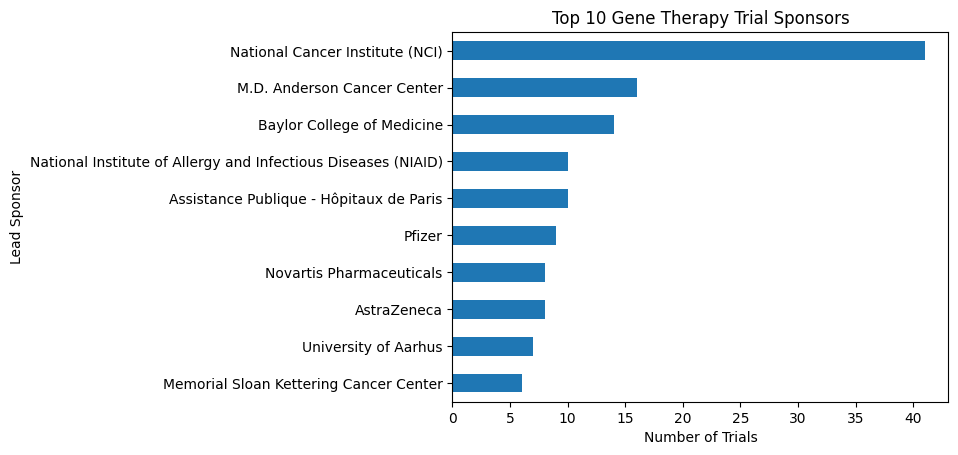

In [31]:
# Plot top sponsors

sponsor_counts.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Gene Therapy Trial Sponsors")
plt.xlabel("Number of Trials")
plt.ylabel("Lead Sponsor")
plt.show()

In [44]:
# Which sponsors focus on which diseases?

# Sponsor specialization

sponsor_disease = df[["nct_id", "lead_sponsor"]].merge(
    conditions_df, on="nct_id", how="left"
)

top_sponsors = sponsor_counts.head(5).index

filtered = sponsor_disease[sponsor_disease["lead_sponsor"].isin(top_sponsors)]

pd.crosstab(filtered["lead_sponsor"], filtered["conditions"])


conditions,ALL,AML,Acinar Cell Carcinoma,Acute Bilineal Leukemia,Acute Biphenotypic Leukemia,Acute Lymphoblastic Leukemia,Acute Myelogenous Leukemia,Adenocarcinoma of the Esophagus,Adenocarcinoma of the Gastroesophageal Junction,Adenocarcinoma of the Prostate,...,Urethral Adenocarcinoma,Urethral Cancer,Urethral Squamous Cell Carcinoma,Uterine Corpus Leiomyosarcoma,Vaginal Adenocarcinoma,"Vaginal Squamous Cell Carcinoma, Not Otherwise Specified",Vulvar Carcinoma,Vulvar Diseases,Vulvar Neoplasms,Wilms Tumor
lead_sponsor,,,,,,,,,,,,,,,,,,,,,
Assistance Publique - Hôpitaux de Paris,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Baylor College of Medicine,1,1,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
M.D. Anderson Cancer Center,0,0,0,1,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
National Cancer Institute (NCI),1,0,1,0,0,0,0,1,1,1,...,1,0,1,1,1,1,1,1,1,1
National Institute of Allergy and Infectious Diseases (NIAID),0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [32]:
# ============================================================
# QUESTION 5:
# Which years saw the most trials?
# ============================================================

# Count trials by start year
year_counts = df["start_year"].dropna().astype(int).value_counts().sort_index()

print("Trials by year:")
print(year_counts)

Trials by year:
start_year
1979     1
1994     2
1995     1
2000     1
2002     1
2003     3
2004     1
2005     1
2006     3
2007     3
2008     8
2009     9
2010     5
2011    10
2012     9
2013    13
2014    21
2015    24
2016    23
2017    44
2018    38
2019    54
2020    52
2021    45
2022    63
2023    58
2024    59
2025    63
2026    31
2028     1
Name: count, dtype: int64


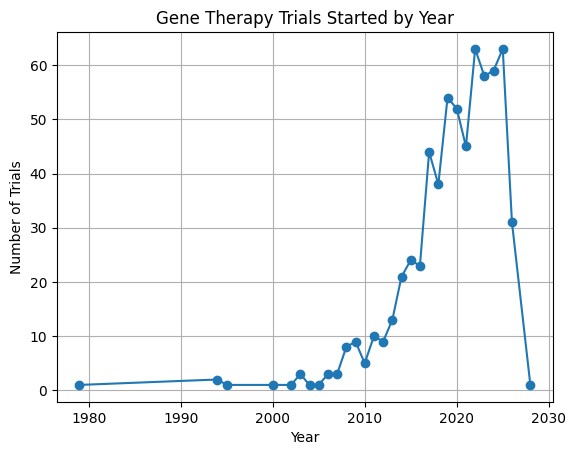

In [33]:
# Plot trials by year

year_counts.plot(kind="line", marker="o")

plt.title("Gene Therapy Trials Started by Year")
plt.xlabel("Year")
plt.ylabel("Number of Trials")
plt.grid(True)
plt.show()

In [34]:
# Find the year with the most trials

top_year = year_counts.idxmax()
top_year_count = year_counts.max()

print(f"The year with the most gene therapy trials was {top_year}, with {top_year_count} trials.")

The year with the most gene therapy trials was 2022, with 63 trials.


In [35]:
# ============================================================
# QUESTION 6:
# Which indications are growing?
# ============================================================

# For this dataset, "indications" = conditions/diseases.
# We merge trial year with conditions so each condition has a year.

condition_year_df = df[["nct_id", "start_year"]].merge(
    conditions_df,
    on="nct_id",
    how="inner"
)

# Drop rows without year
condition_year_df = condition_year_df.dropna(subset=["start_year"])

# Make year an integer
condition_year_df["start_year"] = condition_year_df["start_year"].astype(int)

condition_year_df.head()

,nct_id,start_year,conditions
0,NCT05793190,2021,Alcoholic Liver Disease
8,NCT07213440,2024,Amyotrophic Lateral Sclerosis (ALS)
9,NCT07374913,2021,COL4A1\2
10,NCT07374913,2021,COL4A1-Related Brain Small Vessel Disease With...
12,NCT05502796,2022,Hair Loss


In [36]:
# Count each indication by year

indication_by_year = condition_year_df.groupby(
    ["start_year", "conditions"]
).size().reset_index(name="trial_count")

indication_by_year.head()

,start_year,conditions,trial_count
0,1979,Cystinosis,1
1,1994,"Genetic Disease, Inborn",1
2,1994,"Genetic Disease, X-Linked",1
3,1994,Granuloma,1
4,1994,"Granulomatous Disease, Chronic",1


In [37]:
# Create pivot table:
# rows = years
# columns = indications
# values = number of trials

indication_pivot = indication_by_year.pivot(
    index="start_year",
    columns="conditions",
    values="trial_count"
).fillna(0)

indication_pivot.head()

conditions,7q11.23 Microduplication Syndrome (7DUP),ADA Deficient SCID,ALK Gene Mutation,ALK Gene Rearrangement Positive,ALL,ALS (Amyotrophic Lateral Sclerosis),AMD,AML/MDS,ARID1A Gene Mutation,ART,...,Wilson's Disease,Wiskott- Aldrich Syndrome,X-Linked Chronic Granulomatous Disease,X-Linked Myotubular Myopathy,X-linked Retinoschisis,XRCC2 Gene Mutation,glp1 Agonist,nAMD,wAMD,β-thalassemia
start_year,,,,,,,,,,,,,,,,,,,,,
1979,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1994,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [38]:
# ----------------------------
# Find growing indications
# ----------------------------

# We compare older years vs recent years.
# You can change these cutoffs if needed.

early_period = indication_pivot[indication_pivot.index <= 2018]
recent_period = indication_pivot[indication_pivot.index >= 2019]

early_avg = early_period.mean()
recent_avg = recent_period.mean()

growth = recent_avg - early_avg

growing_indications = growth.sort_values(ascending=False)

print("Top 10 growing indications:")
print(growing_indications.head(10))

Top 10 growing indications:
conditions
Breast Cancer                  1.396825
Non Small Cell Lung Cancer     0.730159
Fabry Disease                  0.666667
Breast Cancer Female           0.666667
Prostate Cancer                0.587302
Cancer                         0.587302
Colo-rectal Cancer             0.555556
HER2-positive Breast Cancer    0.555556
Cardiovascular Diseases        0.555556
Colorectal Cancer              0.507937
dtype: float64


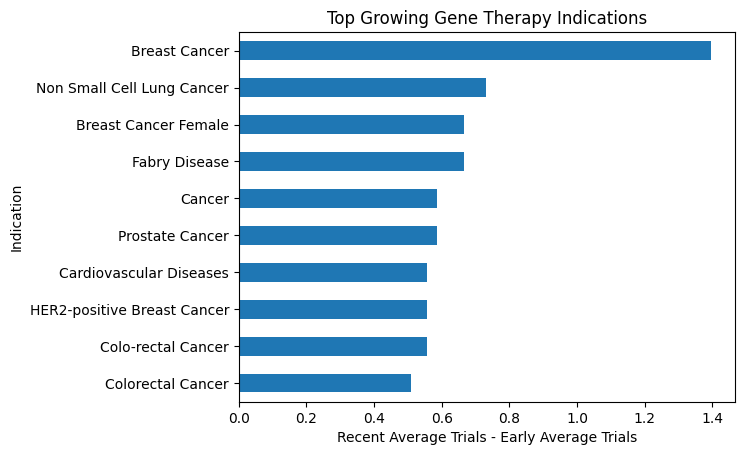

In [39]:
# Plot growing indications

growing_indications.head(10).sort_values().plot(kind="barh")

plt.title("Top Growing Gene Therapy Indications")
plt.xlabel("Recent Average Trials - Early Average Trials")
plt.ylabel("Indication")
plt.show()

In [40]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print("GENE THERAPY CLINICAL TRIALS SUMMARY")
print("------------------------------------")

print("\n1. Disease with most trials:")
print(disease_counts.head(1))

print("\n2. Most common vector/platform keyword:")
print(vector_counts.head(1))

print("\n3. Most common trial phase:")
print(phase_counts.head(1))

print("\n4. Sponsor with most trials:")
print(sponsor_counts.head(1))

print("\n5. Year with most trials:")
print(year_counts.sort_values(ascending=False).head(1))

print("\n6. Fastest growing indication:")
print(growing_indications.head(1))

GENE THERAPY CLINICAL TRIALS SUMMARY
------------------------------------

1. Disease with most trials:
conditions
Breast Cancer    40
Name: count, dtype: int64

2. Most common vector/platform keyword:
CAR-T    13
dtype: int64

3. Most common trial phase:
phases
PHASE2    276
Name: count, dtype: int64

4. Sponsor with most trials:
lead_sponsor
National Cancer Institute (NCI)    41
Name: count, dtype: int64

5. Year with most trials:
start_year
2025    63
Name: count, dtype: int64

6. Fastest growing indication:
conditions
Breast Cancer    1.396825
dtype: float64


In [41]:
# Which vectors are used for which diseases?

# ----------------------------
# Vector vs Disease mapping
# ----------------------------

vector_disease = []

for vector, pattern in vector_keywords.items():
    matches = interventions_df[
        interventions_df["intervention_names"].astype(str).str.contains(
            pattern, case=False, na=False, regex=True
        )
    ]

    merged = matches.merge(conditions_df, on="nct_id", how="left")

    counts = merged["conditions"].value_counts().head(5)

    for disease, count in counts.items():
        vector_disease.append({
            "vector": vector,
            "disease": disease,
            "count": count
        })

vector_disease_df = pd.DataFrame(vector_disease)

vector_disease_df

,vector,disease,count
0,AAV,Macular Degeneration,2
1,AAV,Age-related Maculopathies,2
2,AAV,Age-related Maculopathy,2
3,AAV,"Maculopathies,Age-related",2
4,AAV,"Maculopathy,Age-related",2
5,Adenovirus,Lung Cancer,1
6,Adenovirus,Breast Cancer,1
7,Adenovirus,Cancer,1
8,Lentivirus,Beta-Thalassemia,1
9,Retrovirus,Glioblastoma Multiforme,1


In [42]:
# Which phases are progressing?

# Count early vs late phases

phase_groups = {
    "Early": ["PHASE1", "PHASE1/PHASE2"],
    "Mid": ["PHASE2"],
    "Late": ["PHASE3"]
}

phase_summary = {}

for group, labels in phase_groups.items():
    count = phases_df[phases_df["phases"].isin(labels)]["nct_id"].nunique()
    phase_summary[group] = count

phase_summary = pd.Series(phase_summary)

print(phase_summary)

Early    197
Mid      276
Late      67
dtype: int64


In [43]:
# Oncology vs non-oncology split

# Identify cancer-related trials

cancer_trials = conditions_df[
    conditions_df["conditions"].str.contains(
        "cancer|tumor|carcinoma|lymphoma|leukemia",
        case=False,
        na=False
    )
]

num_cancer = cancer_trials["nct_id"].nunique()
total_trials = df["nct_id"].nunique()

print("Cancer trials:", num_cancer)
print("Total trials:", total_trials)
print("Percentage cancer:", (num_cancer / total_trials) * 100)

Cancer trials: 378
Total trials: 1000
Percentage cancer: 37.8


In [45]:
# What kind of therapies are being used?

interventions_df["intervention_types"].value_counts()

intervention_types
DRUG                   899
OTHER                  301
PROCEDURE              216
BIOLOGICAL             212
GENETIC                100
DIAGNOSTIC_TEST         64
BEHAVIORAL              53
DIETARY_SUPPLEMENT      51
DEVICE                  48
RADIATION               19
COMBINATION_PRODUCT      3
Name: count, dtype: int64

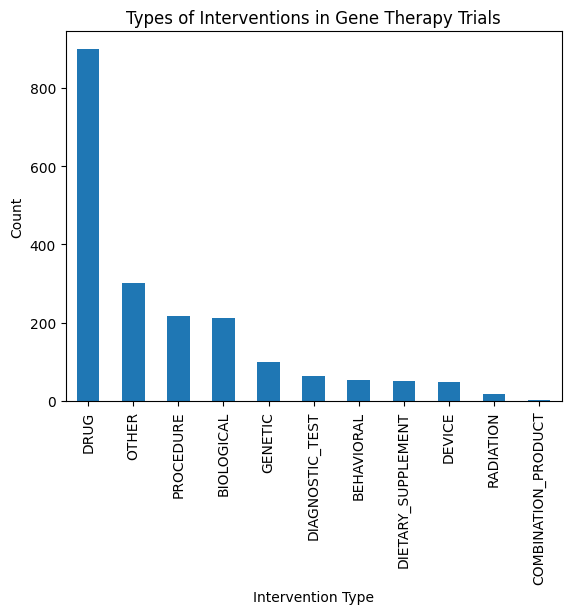

In [46]:
interventions_df["intervention_types"].value_counts().plot(kind="bar")

plt.title("Types of Interventions in Gene Therapy Trials")
plt.xlabel("Intervention Type")
plt.ylabel("Count")
plt.show()

In [47]:
# Top emerging diseases (recent years only)

recent_trends = condition_year_df[
    condition_year_df["start_year"] >= 2020
]

recent_counts = recent_trends["conditions"].value_counts()

print("Top recent diseases:")
print(recent_counts.head(10))

Top recent diseases:
conditions
Breast Cancer                  15
Prostate Cancer                 6
Cancer                          6
Fabry Disease                   6
Non Small Cell Lung Cancer      6
HER2-positive Breast Cancer     5
Colo-rectal Cancer              5
Breast Cancer Female            5
Bladder Cancer                  4
Migraine                        4
Name: count, dtype: int64


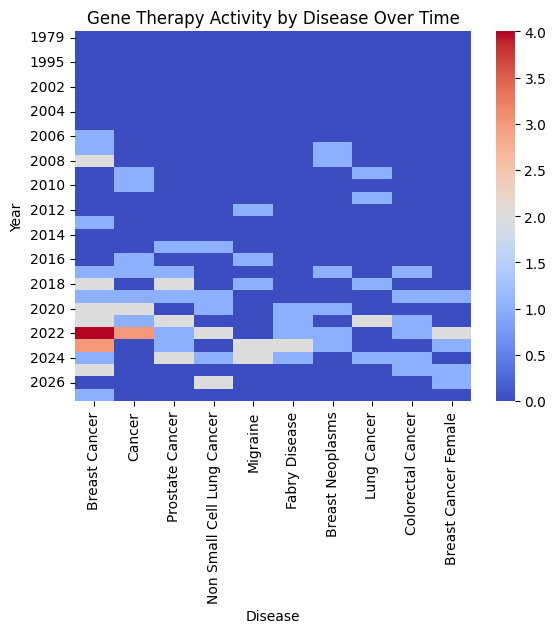

In [48]:
import seaborn as sns

heatmap_data = pd.crosstab(
    condition_year_df["start_year"],
    condition_year_df["conditions"]
)

# Only keep top 10 diseases
top_conditions = heatmap_data.sum().sort_values(ascending=False).head(10).index

heatmap_filtered = heatmap_data[top_conditions]

sns.heatmap(heatmap_filtered, cmap="coolwarm")

plt.title("Gene Therapy Activity by Disease Over Time")
plt.xlabel("Disease")
plt.ylabel("Year")
plt.show()